In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

In [18]:
features_df = pd.read_csv('features.csv')
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
stores_df = pd.read_csv('stores.csv')

In [19]:
merged_train_stores = train_df.merge(stores_df, on='Store', how='inner')
merged_test_stores = test_df.merge(stores_df, on='Store', how='inner')

train_df_final = merged_train_stores.merge(features_df, on=['Store', 'Date', 'IsHoliday'])
test_df_final = merged_test_stores.merge(features_df, on=['Store', 'Date', 'IsHoliday'])


In [20]:
# date formatting
train_df_final['Date'] = pd.to_datetime(train_df_final['Date'])
test_df_final['Date'] = pd.to_datetime(test_df_final['Date'])

train_df_final['Year'] = train_df_final['Date'].dt.year
train_df_final['Month'] = train_df_final['Date'].dt.month
train_df_final['Day'] = train_df_final['Date'].dt.day
train_df_final['dayofweek'] = train_df_final['Date'].dt.dayofweek

test_df_final['Year'] = test_df_final['Date'].dt.year
test_df_final['Month'] = test_df_final['Date'].dt.month
test_df_final['Day'] = test_df_final['Date'].dt.day
test_df_final['dayofweek'] = test_df_final['Date'].dt.dayofweek



# one hot encoding IsHoliday feature
encoder = OneHotEncoder(sparse_output=False, drop='if_binary')
encoded_train_data = encoder.fit_transform(train_df_final[['IsHoliday', 'Type']])
encoded_test_data = encoder.transform(test_df_final[['IsHoliday', 'Type']])
actual_columns = encoder.get_feature_names_out(['IsHoliday', 'Type'])

train_data = pd.DataFrame(encoded_train_data, index=train_df_final.index, columns=actual_columns)
test_data = pd.DataFrame(encoded_test_data, index=test_df_final.index, columns=actual_columns)

In [21]:
X_train = pd.concat([train_data, train_df_final.drop(columns=['IsHoliday', 'Type'])], axis=1)
X_test = pd.concat([test_data, test_df_final.drop(columns=['IsHoliday', 'Type'])], axis=1)

Y_train = X_train[['Weekly_Sales']]
X_train = X_train.drop(columns=['Weekly_Sales', 'Date'])
X_test = X_test.drop(columns=['Date'])

markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
X_train[markdown_cols] = X_train[markdown_cols].fillna(0)
X_test[markdown_cols] = X_test[markdown_cols].fillna(9)


In [22]:
scaler = StandardScaler()
to_scale_cols = []
n = 10

for col in X_train.columns:
    if X_train[col].nunique() > n:
        to_scale_cols.append(col)

X_train = scaler.fit_transform(X_train[to_scale_cols])
X_test = scaler.transform(X_test[to_scale_cols])

In [23]:
input = tf.keras.layers.Input(shape=X_train[1].shape)
x = tf.keras.layers.Dense(64, activation='relu')(input)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
x = tf.keras.layers.Dense(8, activation='relu')(x)
output = tf.keras.layers.Dense(1, activation='linear')(x)

In [ ]:
model = tf.keras.models.Model(inputs=input, outputs=output)
model.compile(optimizer='adam', metrics=['mse'], loss='mse')


X_train_slice, X_test_slice, Y_train_slice, Y_test_slice = train_test_split(X_train, Y_train, test_size=.2)
scaler = StandardScaler()
scaled_Y_train_slice = scaler.fit_transform(Y_train_slice)
scaled_Y_test_slice = scaler.transform(Y_test_slice)
model.fit(X_train_slice, scaled_Y_train_slice, epochs=5, batch_size=32, validation_split=.2)

Epoch 1/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 48s 5ms/step - loss: 491335328.0000 - mse: 491335328.0000 - val_loss: 407206432.0000 - val_mse: 407206432.0000
Epoch 2/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 38s 5ms/step - loss: 395613024.0000 - mse: 395613024.0000 - val_loss: 387675008.0000 - val_mse: 387675008.0000
Epoch 3/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 37s 4ms/step - loss: 376980992.0000 - mse: 376980992.0000 - val_loss: 377306976.0000 - val_mse: 377306976.0000
Epoch 4/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 36s 4ms/step - loss: 373085760.0000 - mse: 373085760.0000 - val_loss: 369316192.0000 - val_mse: 369316192.0000
Epoch 5/5
8432/8432 ━━━━━━━━━━━━━━━━━━━━ 46s 5ms/step - loss: 368043552.0000 - mse: 368043552.0000 - val_loss: 361591552.0000 - val_mse: 361591552.0000


In [ ]:
Y_pred = model.predict(X_test_slice)

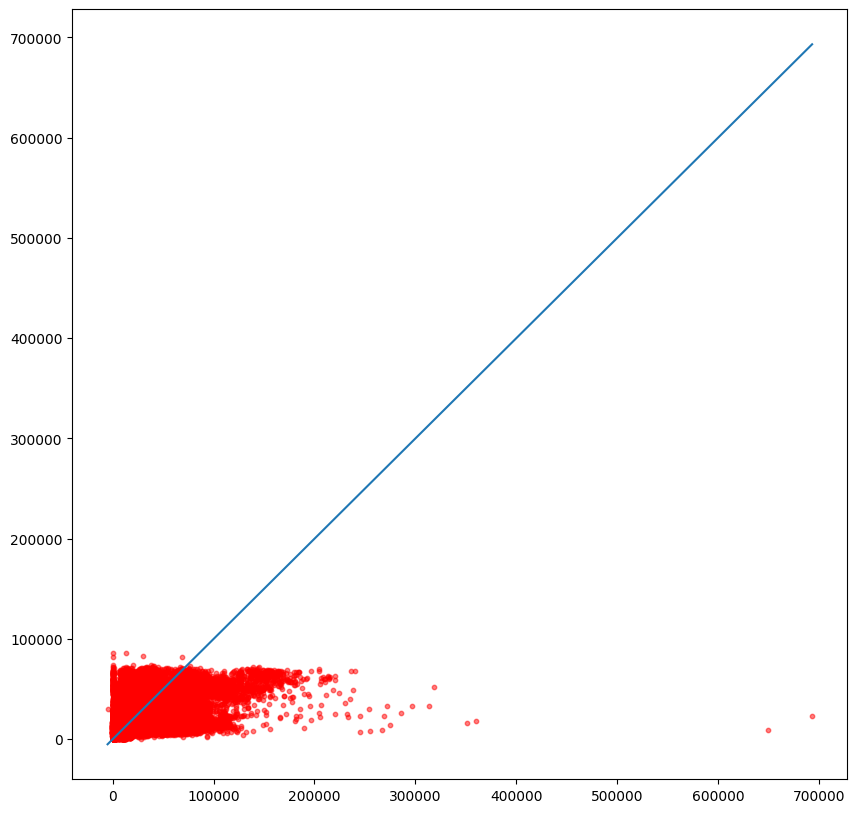

In [31]:
# print(X_test_slice.shape, Y_pred.shape)
plt.figure(figsize=(10, 10))
plt.plot([Y_test_slice.min(), Y_test_slice.max()], [Y_test_slice.min(), Y_test_slice.max()])
plt.scatter(Y_test_slice, Y_pred, alpha=.5, s=10, color='red', label='predictions')
plt.show()